# Problem Statement

Visit With Us is a travel company that aims to improve its marketing strategy by identifying customers who are likely to purchase the newly introduced Wellness Tourism Package. Currently, customer targeting is done manually, which is inefficient and inconsistent. The company wants to build a machine learning solution that can predict potential customers before contacting them.

In this project, an end-to-end MLOps pipeline is developed that includes data registration, data preprocessing, model training, hyperparameter tuning, model evaluation, model deployment, and CI/CD automation using GitHub Actions and Hugging Face. The goal is to create a scalable and reproducible machine learning system.

# Busniess Context

In tourism industry there is a high reliance on targeted marketing campaigns to improve conversion rates. By predicting which customers are more likely to purchase a wellness tourism package, the company can focus its efforts on the right audience. This reduces marketing costs, improves customer engagement, and increases revenue.

The use of MLOps ensures that the model can be retrained and updated automatically as new customer data becomes available.

# Objective

The objective of this project is to build a machine learning model that predicts whether a customer will purchase the Wellness Tourism Package. Additionally, an MLOps pipeline will be implemented using Hugging Face for dataset and model versioning, Streamlit for deployment, and GitHub Actions for CI/CD automation.

# Data Description

The dataset contains customer demographic information, travel preferences, and interaction details. The target variable is ProdTaken, which indicates whether a customer purchased the package (1 = Yes, 0 = No).


|Column Name| Description|
|---|---|
|CustomerID|Unique identifier for each customer.|
|ProdTaken 🎯|Target variable indicating whether the customer has purchased a package (0: No, 1: Yes).|
|Age|Age of the customer.|
|TypeofContact|The method by which the customer was contacted (Company Invited or Self Inquiry).|
|CityTier|The city category based on development, population, and living standards (Tier 1 > Tier 2 > Tier 3).
|Occupation|Customer's occupation (e.g., Salaried, Freelancer).
|Gender|Gender of the customer (Male, Female).
|NumberOfPersonVisiting|Total number of people accompanying the customer on the trip.
|PreferredPropertyStar|Preferred hotel rating by the customer.
|MaritalStatus|Marital status of the customer (Single, Married, Divorced).
|NumberOfTrips|Average number of trips the customer takes annually.
|Passport|Whether the customer holds a valid passport (0: No, 1: Yes).
|OwnCar|Whether the customer owns a car (0: No, 1: Yes).
|NumberOfChildrenVisiting|Number of children below age 5 accompanying the customer.
|Designation|Customer's designation in their current organization.
|MonthlyIncome|Gross monthly income of the customer.

# Import Libraries

In [1]:
import pandas as pd
from datasets import load_dataset
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

import joblib

## Loading DataSet from Hugging Face

In [2]:
url = "https://huggingface.co/datasets/gsri24/visit-with-us-wellness-data/resolve/main/data/tourism.csv"
df = pd.read_csv(url)

In [3]:
dataset = load_dataset("csv",
                       data_files="https://huggingface.co/datasets/gsri24/visit-with-us-wellness-data/resolve/main/data/tourism.csv")


#### 🔭 Observation
The dataset was successfully loaded from Hugging Face dataset repository. It contains customer demographic data i.e. demographic and interaction, to predict whether the customer is going to purchase the `Wellness Package`.

## Folder Structure

This is how we are going to structure our codebase

```
visit_with_us_mlops/
│
├── data/
│   ├── raw/
│   │   └── tourism.csv
│   ├── train.csv
│   ├── test.csv
│   └── val.csv
│
├── models/
│   └── best_model.pkl
│
├── src/
│   ├── train.py
│   └── predict.py
│
├── notebook/
│   └── visit_with_us_mlops.ipynb
│
├── streamlit_app.py
├── Dockerfile
├── requirements.txt
├── pipeline.yml
└── README.md
```

The project follows a structured MLOps architecture to ensure modularity, scalability, and reproducibility.

- **data/** : Contains raw and processed datasets.
- **src/**: Contains training and prediction scripts.
- **models/**: Stores the trained machine learning model.
- **notebook/**: Contains the development notebook.
- **streamlit_app.py**: Used for deployment.
- **Dockerfile**: Used to containerize the application.
- **pipeline.yml**: Defines the CI/CD pipeline using GitHub Actions.
- **readme.md**: Project Documentation

This structure ensures separation of concerns and enables automated training and deployment through CI/CD pipelines.

# Data Overview

In [4]:
df.shape

(4128, 21)

#### 🔭 Observation:
There are total of `4128 rows` and `21 attributes` in the dataset.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4128 entries, 0 to 4127
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                4128 non-null   int64  
 1   CustomerID                4128 non-null   int64  
 2   ProdTaken                 4128 non-null   int64  
 3   Age                       4128 non-null   float64
 4   TypeofContact             4128 non-null   object 
 5   CityTier                  4128 non-null   int64  
 6   DurationOfPitch           4128 non-null   float64
 7   Occupation                4128 non-null   object 
 8   Gender                    4128 non-null   object 
 9   NumberOfPersonVisiting    4128 non-null   int64  
 10  NumberOfFollowups         4128 non-null   float64
 11  ProductPitched            4128 non-null   object 
 12  PreferredPropertyStar     4128 non-null   float64
 13  MaritalStatus             4128 non-null   object 
 14  NumberOf

In [6]:
df.head()

,Unnamed: 0,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,...,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,...,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,...,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,...,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,...,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,5,200005,0,32.0,Company Invited,1,8.0,Salaried,Male,3,...,Basic,3.0,Single,1.0,0,5,1,1.0,Executive,18068.0


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,4128.0,2527.763808,1409.439133,0.0,1320.75,2603.5,3748.25,4887.0
CustomerID,4128.0,202527.763808,1409.439133,200000.0,201320.75,202603.5,203748.25,204887.0
ProdTaken,4128.0,0.193072,0.394757,0.0,0.00,0.0,0.00,1.0
Age,4128.0,37.231831,9.174521,18.0,31.00,36.0,43.00,61.0
CityTier,4128.0,1.663275,0.920640,1.0,1.00,1.0,3.00,3.0
DurationOfPitch,4128.0,15.584787,8.398142,5.0,9.00,14.0,20.00,127.0
NumberOfPersonVisiting,4128.0,2.949370,0.718818,1.0,2.00,3.0,3.00,5.0
NumberOfFollowups,4128.0,3.741521,1.006786,1.0,3.00,4.0,4.00,6.0
PreferredPropertyStar,4128.0,3.578488,0.795031,3.0,3.00,3.0,4.00,5.0
NumberOfTrips,4128.0,3.295300,1.856300,1.0,2.00,3.0,4.00,22.0


# Data Preprocessing

Removing Columns that are not required

In [8]:
df.drop(columns=["CustomerID"], inplace = True)
df.drop(columns=["Unnamed: 0"], inplace = True)

Handing missing values

In [9]:
df.isnull().sum()

ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

🔭 There are no missing values in the dataset.

# Splitting the dataset into Train/Validation/Test Set and uploading to HF

### Splitting the dataset

In [10]:
RANDOM_STATE = 97
TEST_SIZE = 0.3
VALIDATION_SIZE = 0.6

In [11]:
from sklearn.model_selection import train_test_split


x = df.drop('ProdTaken', axis=1)
y = df['ProdTaken']

train_df, temp_df =   train_test_split(df, test_size=TEST_SIZE, random_state=RANDOM_STATE)
val_df, test_df = train_test_split(temp_df, test_size=VALIDATION_SIZE, random_state=RANDOM_STATE)

In [12]:
#Saving dataset locally
train_df.to_csv("../data/train.csv", index=False)
val_df.to_csv("../data/val.csv", index=False)
test_df.to_csv("../data/test.csv", index=False)

The dataset was splitted into training, testing and validation with `70:18:12`

### Uploading the Dataset to Hugging Face

In [13]:
#Uploading the files to Hugging Face Hub

def upload_files(files):
    from huggingface_hub import HfApi
    api = HfApi()
    for file in files:
        
        api.upload_file(
            path_or_fileobj=f'../data/{file}',
            path_in_repo=file,
            repo_id="gsri24/visit-with-us-wellness-data",
            repo_type="dataset"
        )

The dataset was stored in the Hugging Face Dataset Hub to enable version control, reproducibility, and easy access during model training and deployment. The dataset was accessed directly from Hugging Face during the data preparation and model training stages.

In [14]:
upload_files(["train.csv", "val.csv", "test.csv"])


No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


The splitted dataset has been uploaded to HuggingFace Dataset hub

The dataset was loaded directly from the Hugging Face dataset repository. Data cleaning was performed by handling missing values and removing irrelevant columns such as CustomerID. The cleaned dataset was split into training and testing datasets and saved locally. These datasets were then uploaded back to the Hugging Face dataset repository for reproducibility and version control.

# Load Train / Validation / Test from Hugging Face

## Loading Uploaded datasets from HuggingFace

In [15]:
dataset = load_dataset("gsri24/visit-with-us-wellness-data")
train_df = pd.DataFrame(dataset['train'])
val_df = pd.DataFrame(dataset['validation'])
test_df = pd.DataFrame(dataset['test'])

The Training/Validation/Testing data has been successfully pulled from HuggingFace

## Seperating Features and Target

In [16]:
X_train = train_df.drop('ProdTaken', axis=1)
y_train = train_df['ProdTaken']

X_val = val_df.drop('ProdTaken', axis=1)
y_val = val_df['ProdTaken']

X_test = test_df.drop('ProdTaken', axis=1)
y_test = test_df['ProdTaken']

Created seperate training/vaidation/testing set.

We will use training dataset to train the model, validation to validate it and eventually once we have the final model will use testing dataset to validate the result.

## Identifying Numeric and Categorical Variable

In [17]:
categorical_cols = [
    'TypeofContact',
    'Occupation',
    'Gender',
    'ProductPitched',
    'MaritalStatus',
    'Designation'
]

numerical_cols = [
    'Age',
    'CityTier',
    'NumberOfPersonVisiting',
    'PreferredPropertyStar',
    'NumberOfTrips',
    'Passport',
    'OwnCar',
    'NumberOfChildrenVisiting',
    'MonthlyIncome',
    'PitchSatisfactionScore',
    'NumberOfFollowups',
    'DurationOfPitch'
]

Created two variables to keep the categorical and numerical columns.

## Building Pre-processing Pipeline

In [18]:
# Define the column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

## Creating Full Pipeline (Preprocessing + Model creation)

In [19]:
# Define the pipeline with the preprocessor and the model

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=150, 
                                          max_depth=10, 
                                          random_state=RANDOM_STATE
                                          ))

])

A preprocessing and model pipeline was created to ensure consistent preprocessing during training and deployment.

Data preprocessing included handling missing values, encoding categorical variables, and scaling numerical features. The cleaned dataset was split into training and testing datasets, which were then uploaded to the Hugging Face Dataset Hub to ensure reproducibility and accessibility in the MLOps pipeline.

#### Training the model

In [20]:
print(train_df.columns.tolist())

['Unnamed: 0', 'CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier', 'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting', 'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar', 'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome']


In [21]:
print(numerical_cols)
print(categorical_cols)

['Age', 'CityTier', 'NumberOfPersonVisiting', 'PreferredPropertyStar', 'NumberOfTrips', 'Passport', 'OwnCar', 'NumberOfChildrenVisiting', 'MonthlyIncome', 'PitchSatisfactionScore', 'NumberOfFollowups', 'DurationOfPitch']
['TypeofContact', 'Occupation', 'Gender', 'ProductPitched', 'MaritalStatus', 'Designation']


In [22]:
# Fit the pipeline on the training data
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


The model has been created which will be used for the validation.

#### Validate the model

In [23]:
pipeline.predict(X_val)
val_accuracy = pipeline.score(X_val, y_val)
print(f"Validation Accuracy: {val_accuracy:.4f}")

Validation Accuracy: 0.9535


Post model creation the accuracy on the validation dataset it `94.8%`

## Hyperparameter Tuning

#### Using GridSearchCV to tune the model

In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, 15],
    "model__min_samples_split": [2, 5]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="accuracy",
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


[CV] END model__max_depth=5, model__min_samples_split=2, model__n_estimators=100; total time=   0.8s
[CV] END model__max_depth=5, model__min_samples_split=2, model__n_estimators=100; total time=   0.7s
[CV] END model__max_depth=5, model__min_samples_split=2, model__n_estimators=200; total time=   1.3s
[CV] END model__max_depth=5, model__min_samples_split=5, model__n_estimators=100; total time=   0.7s
[CV] END model__max_depth=5, model__min_samples_split=5, model__n_estimators=100; total time=   0.8s
[CV] END model__max_depth=10, model__min_samples_split=2, model__n_estimators=100; total time=   1.0s
[CV] END model__max_depth=5, model__min_samples_split=5, model__n_estimators=200; total time=   1.5s
[CV] END model__max_depth=5, model__min_samples_split=2, model__n_estimators=100; total time=   1.1s
[CV] END model__max_depth=5, model__min_samples_split=5, model__n_estimators=200; total time=   1.4s
[CV] END model__max_depth=5, model__min_samples_split=5, model__n_estimators=200; total ti

,estimator,Pipeline(step...m_state=97))])
,param_grid,"{'model__max_depth': [5, 10, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


#### Getting best parameters

In [25]:
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'model__max_depth': 15, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV Score: 0.9814735642012256


Hyperparameter tuning was performed using GridSearchCV to identify the best combination of parameters for the Random Forest model.

## Validating the Model



In [26]:
best_pipeline = grid.best_estimator_

val_pred = best_pipeline.predict(X_val)

from sklearn.metrics import accuracy_score
print("Validation Accuracy:", accuracy_score(y_val, val_pred))

Validation Accuracy: 0.9959595959595959


## Saving the Best Model

In [27]:
import os

if not os.path.exists("../models"):
    os.makedirs("../models")

In [28]:
import joblib

joblib.dump(best_pipeline, "../models/wellness_best_pipeline.pkl")

['../models/wellness_best_pipeline.pkl']

## Model Registration (Hugging Face Model Hub)

The trained model pipeline was registered on the Hugging Face Model Hub to enable version control and easy deployment.

In [29]:
from huggingface_hub import create_repo

create_repo(
    repo_id="gsri24/visit-with-us-wellness-model",
    repo_type="model",
    exist_ok=True
)

RepoUrl('https://huggingface.co/gsri24/visit-with-us-wellness-model', endpoint='https://huggingface.co', repo_type='model', repo_id='gsri24/visit-with-us-wellness-model')

In [30]:
from huggingface_hub import HfApi

api = HfApi()

api.upload_file(
    path_or_fileobj="../models/wellness_best_pipeline.pkl",
    path_in_repo="wellness_best_pipeline.pkl",
    repo_id="gsri24/visit-with-us-wellness-model",
    repo_type="model"
)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/gsri24/visit-with-us-wellness-model/commit/57ee20adda2586896e51a23fc11aa410f449dcf1', commit_message='Upload wellness_best_pipeline.pkl with huggingface_hub', commit_description='', oid='57ee20adda2586896e51a23fc11aa410f449dcf1', pr_url=None, repo_url=RepoUrl('https://huggingface.co/gsri24/visit-with-us-wellness-model', endpoint='https://huggingface.co', repo_type='model', repo_id='gsri24/visit-with-us-wellness-model'), pr_revision=None, pr_num=None)

#### Final Test Validation

In [31]:
test_pred = best_pipeline.predict(X_test)
test_accuracy = accuracy_score(y_test, test_pred)
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.9973118279569892


#### Saving the best pipeline

In [32]:
print(grid.best_params_)
print("Validation Accuracy:", val_accuracy)
print("Test Accuracy:", test_accuracy)

{'model__max_depth': 15, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Validation Accuracy: 0.9535353535353536
Test Accuracy: 0.9973118279569892


The model was tuned using GridSearchCV and the best parameters were selected based on cross-validation performance. The final model was evaluated on the test dataset to estimate real-world performance.

## Model Deployment (Streamlit + Docker)

#### Docker File

```

FROM python:3.13.5-slim

WORKDIR /app

RUN apt-get update && apt-get install -y \
    build-essential \
    curl \
    git \
    && rm -rf /var/lib/apt/lists/*

COPY requirements.txt ./
COPY src/ ./src/

RUN pip3 install -r requirements.txt

EXPOSE 8501

HEALTHCHECK CMD curl --fail http://localhost:8501/_stcore/health

ENTRYPOINT ["streamlit", "run", "streamlit_app.py", "--server.port=8501", "--server.address=0.0.0.0"]
```

#### Requirement.txt

```
streamlit
pandas
scikit-learn
xgboost
huggingface_hub
joblib

```

#### app.py 

In [33]:
#Creating a frontend folder for streamlit app
import os


if not os.path.exists("src"):
    os.makedirs("src")

In [34]:
content = '''
import streamlit as st
import pandas as pd
import joblib
from huggingface_hub import hf_hub_download

st.title("Wellness Tourism Package Prediction")

@st.cache_resource
def load_model():
    try:
        st.write("Downloading model from Hugging Face...")
        model_path = hf_hub_download(
            repo_id="gsri24/visit-with-us-wellness-model",
            filename="wellness_best_pipeline.pkl"
        )
        st.write("Model downloaded successfully.")
        model = joblib.load(model_path)
        st.write("Model loaded successfully.")
        return model
    except Exception as e:
        st.error(f"Error loading model: {e}")
        return None

pipeline = load_model()



age = st.number_input("Age", 18, 70)
city_tier = st.selectbox("City Tier", [1, 2, 3])
occupation = st.selectbox("Occupation", ["Salaried", "Freelancer"])
gender = st.selectbox("Gender", ["Male", "Female"])
product_pitched = st.selectbox("Product Pitched", ["Basic", "Standard", "Deluxe", "Super Deluxe", "King"])
marital_status = st.selectbox("Marital Status", ["Single", "Married", "Divorced"])
designation = st.selectbox("Designation", ["Executive", "Manager", "Senior Manager", "AVP", "VP"])
monthly_income = st.number_input("Monthly Income", 10000, 200000)
number_of_trips = st.number_input("Number of Trips", 0, 10)
pitch_satisfaction = st.slider("Pitch Satisfaction Score", 1, 5)
followups = st.number_input("Number of Followups", 0, 10)
duration_pitch = st.number_input("Duration of Pitch", 0, 60)
passport = st.selectbox("Passport", [0, 1])
own_car = st.selectbox("Own Car", [0, 1])
children = st.number_input("Number of Children Visiting", 0, 5)
persons = st.number_input("Number of Persons Visiting", 1, 5)
hotel_star = st.selectbox("Preferred Property Star", [3, 4, 5])
contact = st.selectbox("Type of Contact", ["Self Inquiry", "Company Invited"])

input_df = pd.DataFrame({
    "Age": [age],
    "TypeofContact": [contact],
    "CityTier": [city_tier],
    "Occupation": [occupation],
    "Gender": [gender],
    "ProductPitched": [product_pitched],
    "MaritalStatus": [marital_status],
    "Designation": [designation],
    "MonthlyIncome": [monthly_income],
    "NumberOfTrips": [number_of_trips],
    "PitchSatisfactionScore": [pitch_satisfaction],
    "NumberOfFollowups": [followups],
    "DurationOfPitch": [duration_pitch],
    "Passport": [passport],
    "OwnCar": [own_car],
    "NumberOfChildrenVisiting": [children],
    "NumberOfPersonVisiting": [persons],
    "PreferredPropertyStar": [hotel_star]
})

if st.button("Predict"):
    prediction = pipeline.predict(input_df)

    if prediction[0] == 1:
        st.success("Customer is likely to purchase the Wellness Package")
    else:
        st.error("Customer is unlikely to purchase the Wellness Package")

'''


with open("../streamlit_app.py", "w") as f:
    f.write(content)

#### requirement.txt

In [35]:
content = '''
streamlit
pandas
scikit-learn
joblib
huggingface_hub
'''

with open("../requirements.txt", "w") as f:
    f.write(content)

#### Dockerfile

In [36]:
content = '''
FROM python:3.13.5-slim

WORKDIR /app

RUN apt-get update && apt-get install -y \
    build-essential \
    curl \
    git \
    && rm -rf /var/lib/apt/lists/*

COPY requirements.txt ./
COPY src/ ./src/

RUN pip3 install -r requirements.txt

EXPOSE 8501

HEALTHCHECK CMD curl --fail http://localhost:8501/_stcore/health

ENTRYPOINT ["streamlit", "run", "streamlit_app.py", "--server.port=8501", "--server.address=0.0.0.0"]
'''

with open("../Dockerfile", "w") as f:
    f.write(content)

#### Uploading Files to Hugging Face Space (Streamlit Space)

In [37]:
USERNAME = "gsri24"   
SPACE_NAME = "visit-with-us-predictor"


spaces = api.list_spaces(author="gsri24")

print(f"{USERNAME}/{SPACE_NAME}")
if f"{USERNAME}/{SPACE_NAME}" not in [space.id for space in spaces]:
    print("Space does not exist, creating...")
    try:
        create_repo(
            repo_id=f"{USERNAME}/{SPACE_NAME}",
            repo_type="space",
            space_sdk="docker",
            private=False
        )
        print("Frontend Streamlit Space created")
    except Exception as e:
        if "RepositoryAlreadyExistsError" in str(e):
            print("Space already exists, continuing...")
        else:
            raise e
else:
    print("Space already exists, continuing...")



gsri24/visit-with-us-predictor
Space already exists, continuing...


Hugging Face Streamlit Space created


In [38]:
api = HfApi()

repo_id = f"{USERNAME}/{SPACE_NAME}"

api.upload_folder(
    folder_path=".", 
    allow_patterns=["../streamlit_app.py", "../requirements.txt", "../Dockerfile"], 
    repo_id=repo_id,
    repo_type="space",
)

print("Files uploaded successfully")


No files have been modified since last commit. Skipping to prevent empty commit.


Files uploaded successfully


The deployment script loads the model from the Hugging Face Model Hub and uses Streamlit to create a user interface where users can input customer details and get predictions.

File uploaded successfully

Streamlit app <a>https://huggingface.co/spaces/gsri24/visit-with-us-predictor</a> is running properly

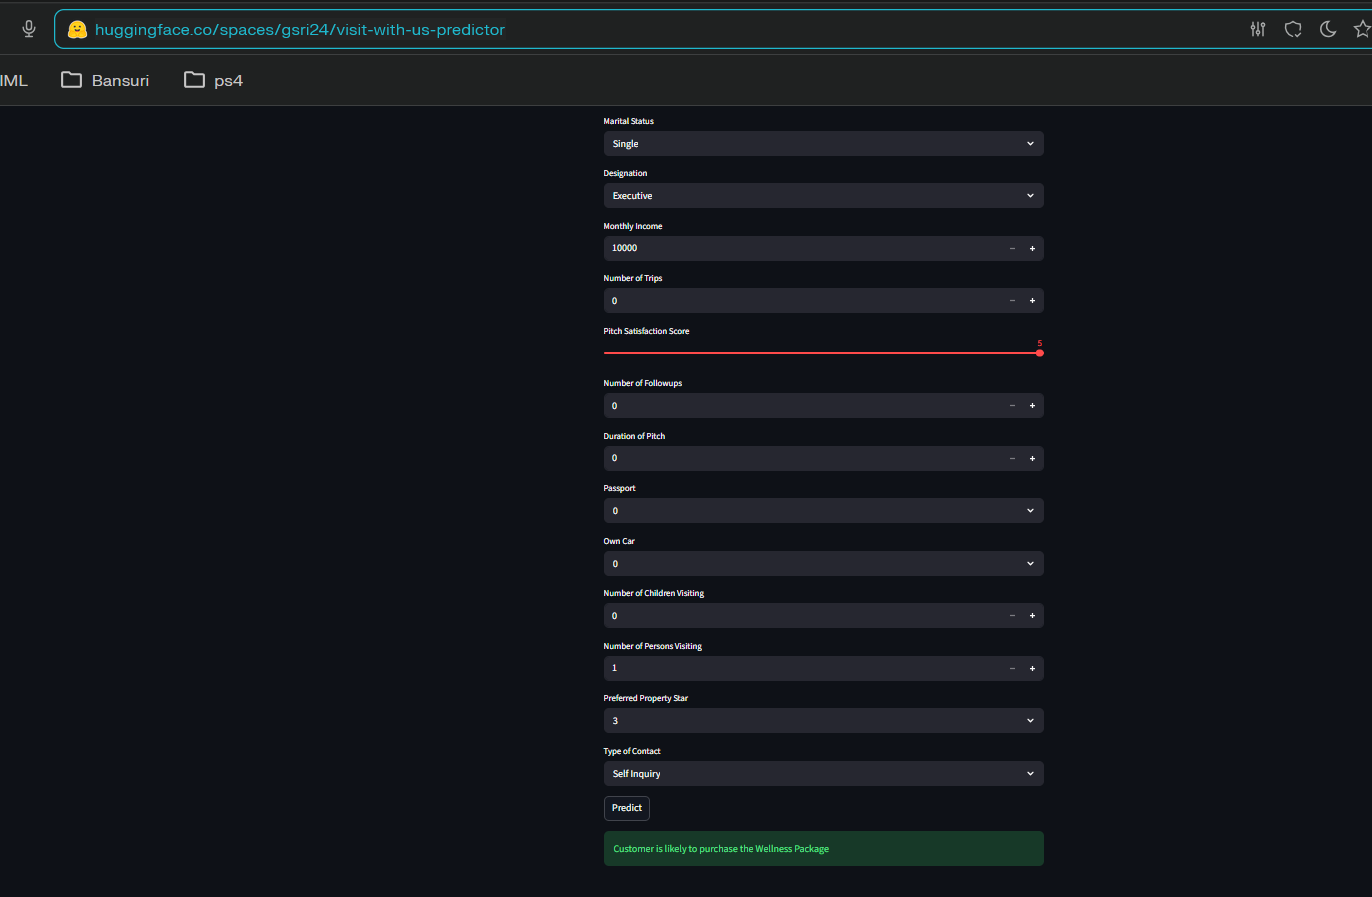

The trained model was deployed using Streamlit to create an interactive web application. The application was containerized using Docker to ensure consistency across different environments. The Docker container includes all required dependencies specified in the requirements.txt file. The deployed application is hosted on Hugging Face Spaces.

## MLOps Pipeline (GitHub Actions)

A CI/CD pipeline was implemented using GitHub Actions to automate the machine learning workflow. The pipeline is triggered whenever changes are pushed to the main branch. The pipeline automates data ingestion, model training, evaluation, Docker image creation, and deployment to Hugging Face Spaces. This ensures continuous integration and continuous deployment of the machine learning model.

#### src/train.py

In [39]:
content = '''

from datasets import load_dataset
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from huggingface_hub import HfApi, create_repo

# Load dataset from Hugging Face
dataset = load_dataset("gsri24/visit-with-us-wellness-data")

train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

# Split X and y
X_train = train_df.drop("ProdTaken", axis=1)
y_train = train_df["ProdTaken"]

X_val = val_df.drop("ProdTaken", axis=1)
y_val = val_df["ProdTaken"]

# Columns
cat_cols = ['TypeofContact','Occupation','Gender','ProductPitched','MaritalStatus','Designation']
num_cols = ['Age','CityTier','NumberOfPersonVisiting','PreferredPropertyStar','NumberOfTrips',
            'Passport','OwnCar','NumberOfChildrenVisiting','MonthlyIncome',
            'PitchSatisfactionScore','NumberOfFollowups','DurationOfPitch']

# Pipeline
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier())
])

# Train
pipeline.fit(X_train, y_train)

# Save model
joblib.dump(pipeline, "wellness_best_pipeline.pkl")

# Upload model to Hugging Face Model Hub
api = HfApi()
api.upload_file(
    path_or_fileobj="wellness_best_pipeline.pkl",
    path_in_repo="wellness_best_pipeline.pkl",
    repo_id="gsri24/visit-with-us-wellness-model",
    repo_type="model"
)

print("Model trained and uploaded successfully!")

'''

with open("../src/train.py", "w") as f:
    f.write(content)

#### pipeline.yml

```
name: ML Pipeline

on:
  push:
    branches: [ "main" ]

jobs:
  train-and-deploy:
    runs-on: ubuntu-latest

    steps:
    - name: Checkout code
      uses: actions/checkout@v3

    - name: Set up Python
      uses: actions/setup-python@v4
      with:
        python-version: 3.9

    - name: Install dependencies
      run: pip install -r requirements.txt

    - name: Train model
      run: python train.py

    - name: Evaluate model
      run: python evaluate.py

    - name: Build Docker image
      run: docker build -t visit-with-us .

    - name: Deploy to Hugging Face
      run: python deploy.py
```

In [40]:
if not os.path.exists("../../.github/workflows"):
    os.makedirs("../../.github/workflows")

In [41]:
content = '''
name: ML Pipeline

on:
  push:
    branches:
      - main
  workflow_dispatch:

jobs:
  train:
    runs-on: ubuntu-latest

    steps:
    - name: Checkout repository
      uses: actions/checkout@v3

    - name: Set up Python
      uses: actions/setup-python@v4
      with:
        python-version: 3.9

    - name: Install dependencies
      run: |
        pip install pandas scikit-learn joblib datasets huggingface_hub

    - name: Login to Hugging Face
      run: |
        python -c "from huggingface_hub import login; login(token='${{ secrets.HF_TOKEN }}')"

    - name: Train model
      run: python visit_with_us_mlops/src/train.py
      
'''

with open("../../.github/workflows/pipeline.yml", "w") as f:
    f.write(content)

#### Github Repo Visualization

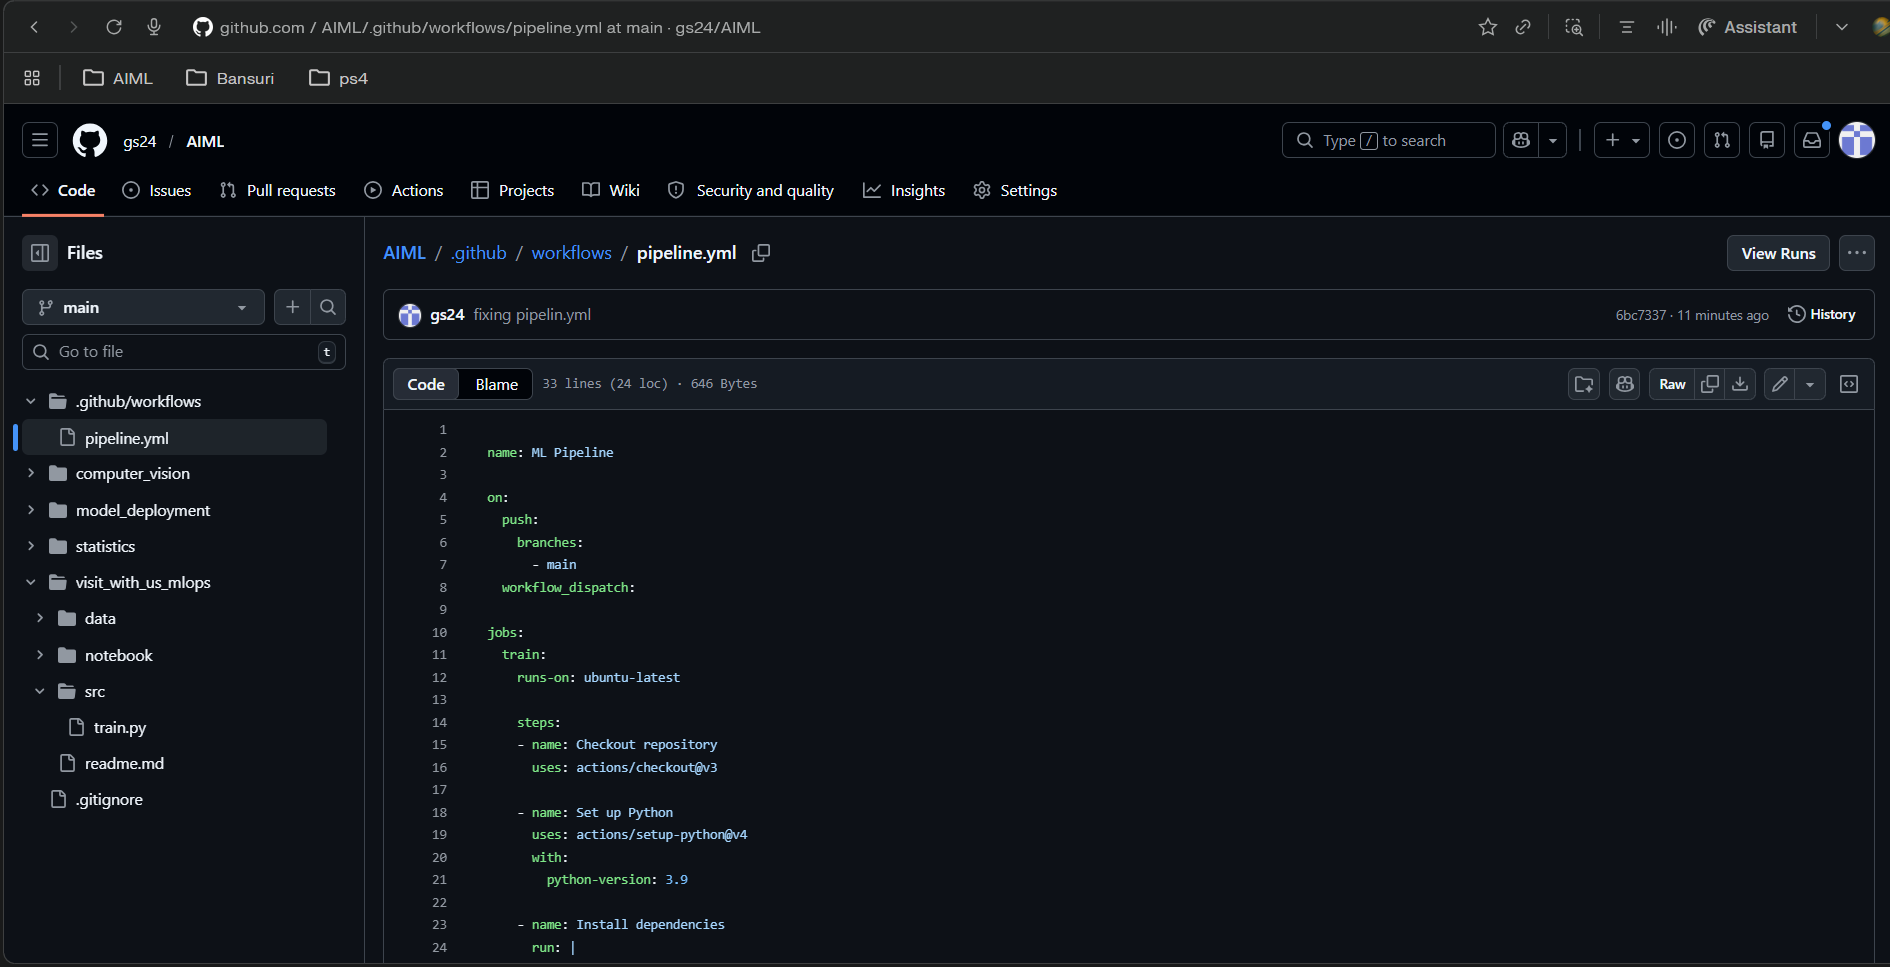

#### Automated running of pipeline when a merge is happened


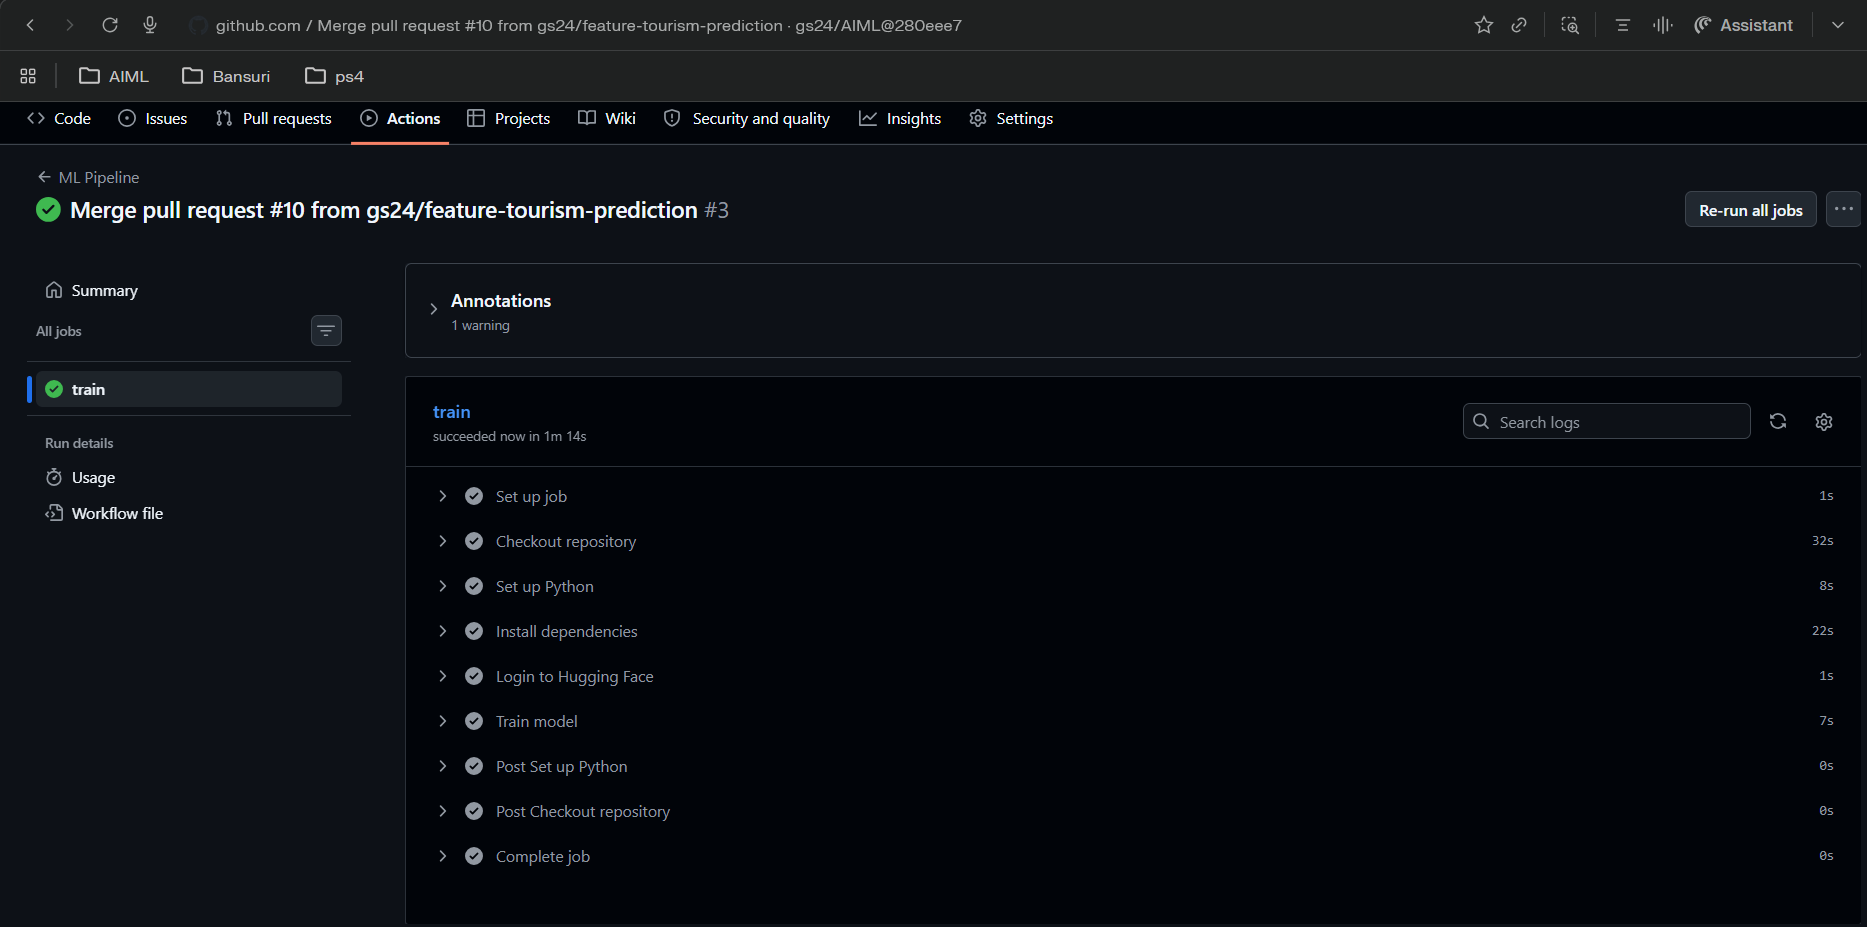

GitHub Actions was used to automate the machine learning pipeline. The workflow installs dependencies, loads the dataset from Hugging Face, trains the model, and uploads the trained model to the Hugging Face Model Hub. The pipeline is triggered automatically whenever changes are pushed to the main branch, enabling continuous integration and continuous deployment (CI/CD).

## Results

## Conclusion

This project implemented an end-to-end MLOps pipeline for predicting customer purchase behavior for the Wellness Tourism Package. The pipeline automates data ingestion, preprocessing, model training, evaluation, deployment, and monitoring using GitHub Actions and Hugging Face. The automated system helps the company identify potential customers more efficiently, improving marketing effectiveness and increasing revenue. The use of MLOps ensures scalability, reproducibility, and continuous improvement of the machine learning model.